## DATA CLEANING AND MINHASH SIGNATURE CREATION

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy as np
import random

#Used to show completion on large dataset
from tqdm import tqdm


## The code below is code reused from homework 1 to clean text with some additional code to fix up the lyrics. It also removes songs under a minute and drops duplicates

In [2]:
# ----- Begin by pulling data into a "songs" DataFrame to be used for recommendation -------
def clean_text(text):
    cleaned = text.lower()
    cleaned = cleaned.replace("!", " ").replace('?', ' ').replace(",", " ")
    cleaned = re.sub(r'[^a-z\s]', " ", cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned)
    cleaned = cleaned.strip()
    return cleaned

songs = pd.read_csv("songs.csv")
# Ensure songs are over a minute
songs = songs[songs["duration_ms"] >= 60000]
songs["lyrics"] = songs["lyrics"].str.replace("\n", " ")
songs["lyrics"] = songs["lyrics"].apply(lambda x: clean_text(str(x)))
songs = songs.drop_duplicates(subset=["name", "artists"]).reset_index(drop=True)

In [3]:
songs.head(1)

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,HELLYEAH,0.415,0.605,7,-11.157,1,0.0575,0.00116,0.838,0.471,0.193,100.059,79500.0,he said he came from jamaica he owned a couple...


In [7]:
def create_shingles(text, k):
    shingles = set()
    for i in range(len(text) - k + 1):
        shingle = text[i:i+k]
        shingles.add(shingle)
    return shingles


# Modified this function to use numpy intead of the original to make computation much faster (~2hrs -> ~10mins)
def minhash_signature(shingle_set, hash_functions):
    if not shingle_set:
        return [0] * len(hash_functions)

    shingle_ints = []
    for shingle in shingle_set:
        shingle_ints.append(hash(shingle) % (2**31))
    shingle_ints = np.array(shingle_ints)

    signature = []
    for hash_func in hash_functions:
        min_hash = hash_func(shingle_ints).min()
        signature.append(min_hash)
    
    return signature

 

def generate_hash_functions(num_hashes, p=2**31 - 1):
    hash_functions = []
    
    for _ in range(num_hashes):
        a = random.randint(1, p-1)
        b = random.randint(1, p-1)

        def hash_func(x, a=a, b=b, p=p):
            return (a * x + b) % p
        
        hash_functions.append(hash_func)
    
    return hash_functions



num_hashes = 100
hash_functions = generate_hash_functions(num_hashes)

signatures = []
for text in tqdm(songs["lyrics"]):
    shingles = create_shingles(text, 5)
    signature = minhash_signature(shingles, hash_functions)
    signatures.append(signature)

songs["signature"] = signatures

100%|██████████| 848416/848416 [08:21<00:00, 1690.85it/s] 


### The below cell loads signatures to save time recalculating them

In [8]:
## Save or load the signatures, but they've been save before so only load is necessary
# np.save("signatures.npy", signatures)
signatures = np.load("signatures.npy")
songs = songs.reset_index(drop=True)
songs["signature"] = list(signatures)
songs.head(1)

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,signature
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,HELLYEAH,0.415,0.605,7,-11.157,1,0.0575,0.00116,0.838,0.471,0.193,100.059,79500.0,he said he came from jamaica he owned a couple...,"[2708555, 646435, 191652, 821648, 773793, 9783..."


## This code runs the similarity search for signatures compared to the input song signature

In [59]:
## These methods have been implemented from Homework 1 Part C

## Counts how many positions have matching values
def signature_similarity(sig1, sig2):
    matches = sum(1 for i in range(len(sig1)) if sig1[i] == sig2[i])
    return matches / len(sig1)


## Checks that the song name and artist name match up with songs dataframe entry. Chose artist and song name since many songs have the same name
def find_song_index(song_name, artist):
    matches = songs[(songs["name"].str.lower() == song_name.lower()) & (songs["artists"].str.lower() == artist.lower())]
    if len(matches) == 0:
        return None
    return matches.index[0]


def find_similar_songs(song_name, artist_name):
    song_index = find_song_index(song_name, artist_name)

    ## Checks if the wanted song exists in the database
    if song_index is None:
        print(f"Couldn't find {song_name} by: {artist_name}")
        return
    
    song_signature = songs["signature"].iloc[song_index]
    num_songs = len(songs)
    similarities = []

    for i in tqdm(range(num_songs)):
        check_signature = songs["signature"].iloc[i]
        score = signature_similarity(song_signature, check_signature)
        similarities.append((i, score))

    ## Found on geeksforgeeks how to sort list an print the 10 largest elements
    best_10 = sorted(similarities, key=lambda tup: tup[1], reverse=True)[1: 11]
    best_10_return = []
    count = 1

    print(f"---- Here are {song_name} by {artist_name}'s most similar songs ----\n")
    for index, score in best_10:
        print(f"{count}. {songs["name"].iloc[index]} by: {songs["artists"].iloc[index]} | Similarity Score = {score}")
        count += 1


    return best_10

In [63]:
print(find_similar_songs("stuck on you", "giveon"))

100%|██████████| 848416/848416 [00:12<00:00, 69870.13it/s]


---- Here are stuck on you by giveon's most similar songs ----

1. Belong to the World by: Clever | Similarity Score = 0.18
2. Blame It On The Rain by: He Is We | Similarity Score = 0.18
3. Falling by: Keahiwai | Similarity Score = 0.18
4. Fine, Great by: Modern Baseball | Similarity Score = 0.17
5. I Believe in Your Love by: Charles Bradley | Similarity Score = 0.17
6. I Think It's Going To Rain by: Blacktop | Similarity Score = 0.17
7. In My Dreams by: Lionel Richie | Similarity Score = 0.17
8. Intentions by: Duumu, GLNNA | Similarity Score = 0.17
9. Me & U by: TWOPILOTS | Similarity Score = 0.17
10. Springblown by: Laura Nyro | Similarity Score = 0.17
[(73402, 0.18), (83001, 0.18), (223634, 0.18), (232809, 0.17), (311744, 0.17), (323031, 0.17), (341688, 0.17), (347881, 0.17), (439950, 0.17), (641843, 0.17)]


## BEGINNING OF K_MEANS AND PCA

In [13]:
## Use sklearn.preprocessing import LabelEncoder to create unique values to represent non float values
songs["key"].unique()

<StringArray>
[   '7',    '5',    '2',    '1',    '9',    '0',    '4',    'F',    '6',
    '8',  '7.0',   'C#',  '8.0',    'C',    '3',   'A#', '10.0',   '11',
    'A',   'D#', '11.0',   '10',  '1.0',    'E',  '6.0',    'G',  '0.0',
    'D',   'F#',  '2.0',  '5.0',    'B',  '9.0',  '4.0',   'G#',  '3.0']
Length: 36, dtype: str

In [14]:
## Drop the decimal to make numbers uniform
songs["key"] = songs["key"].astype(str)
songs["key"] = songs["key"].str.replace(".0", "")
##
key_to_num_map = {"C": 0, "C#": 1, "D": 2, "D#": 3, "E": 4, "F": 5, "F#": 6, "G": 7, "G#": 8, "A": 9, "A#": 10, "B": 11,
                  "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "6": 6, "7": 7, "8": 8, "9": 9, "10": 10, "11": 11}
songs["key"] = songs["key"].map(key_to_num_map)




In [15]:
## Shows that all the values have been made uniform
songs["key"].sort_values().unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [16]:
songs["mode"] = songs["mode"].astype(str)
songs["mode"] = songs["mode"].str.replace(".0", "")

mode_to_num_map = {"0": 0, "1": 1, "Major": 1, "Minor": 0}
songs["mode"] = songs["mode"].map(mode_to_num_map)

In [17]:
songs["mode"].unique()

array([1, 0])

100%|██████████| 5/5 [01:07<00:00, 13.43s/it]


Text(0.5, 1.0, 'Lineplot comparing how k affects WCSS values')

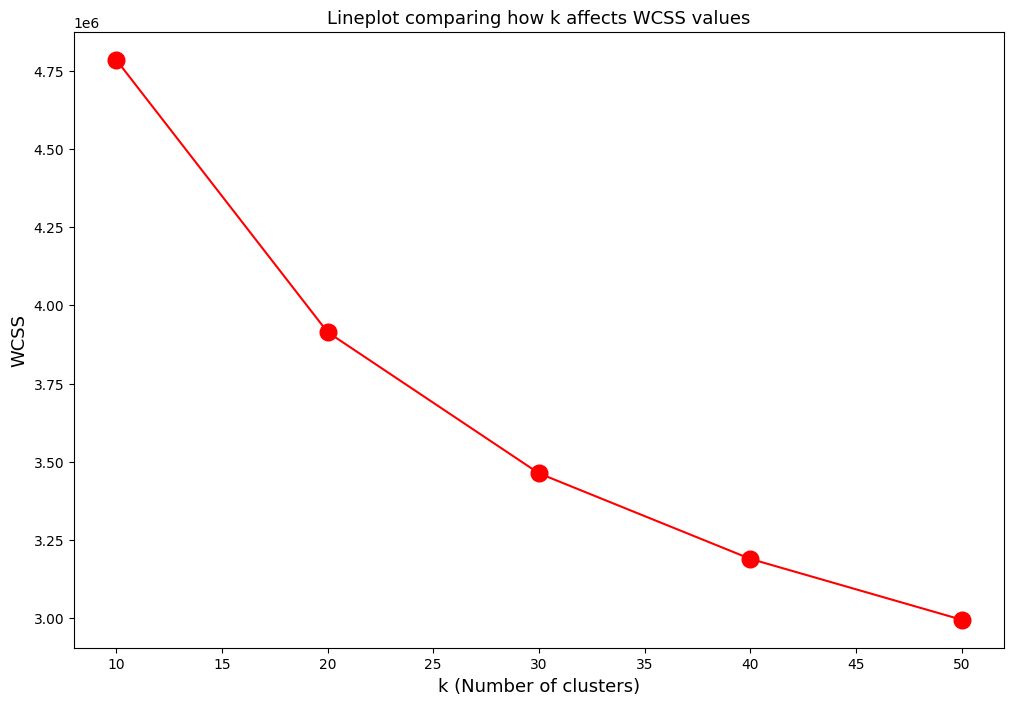

In [18]:
## -------- Run K-means to find best number of clusters -------------- ##
## Note: References Homework 2: Problem 2 Part C

# Extract sound features into arrays per song
features = ["danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
sound_features = songs[features].values

# Normalize feature values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(sound_features)

WCSS = []

## K values chosen for ideal number of genres of categories of music
k_list = np.array([10, 20, 30, 40, 50])
for k in tqdm(k_list):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = model.fit_predict(scaled_features)
    centroids = model.cluster_centers_
    WCSS.append(model.inertia_)

plt.figure(figsize=(12, 8))
plt.plot(k_list, np.array(WCSS), 'o-r', markersize=12)
plt.xlabel('k (Number of clusters)', fontsize=13)
plt.ylabel ('WCSS', fontsize=13)
plt.title("Lineplot comparing how k affects WCSS values", fontsize=13)


## Observing the graph I will choose the number of clusters to be 20 since that is where the elbow of the graph begins

#### The main issue I had after this step was trying to plot kmeans in two dimensions when I have a bunch of features. My solution to this was to use PCA to reduce the dimensionality of the data while also reducing the number of features used to represent the data. So I researched how to do this process and it can be seen below.

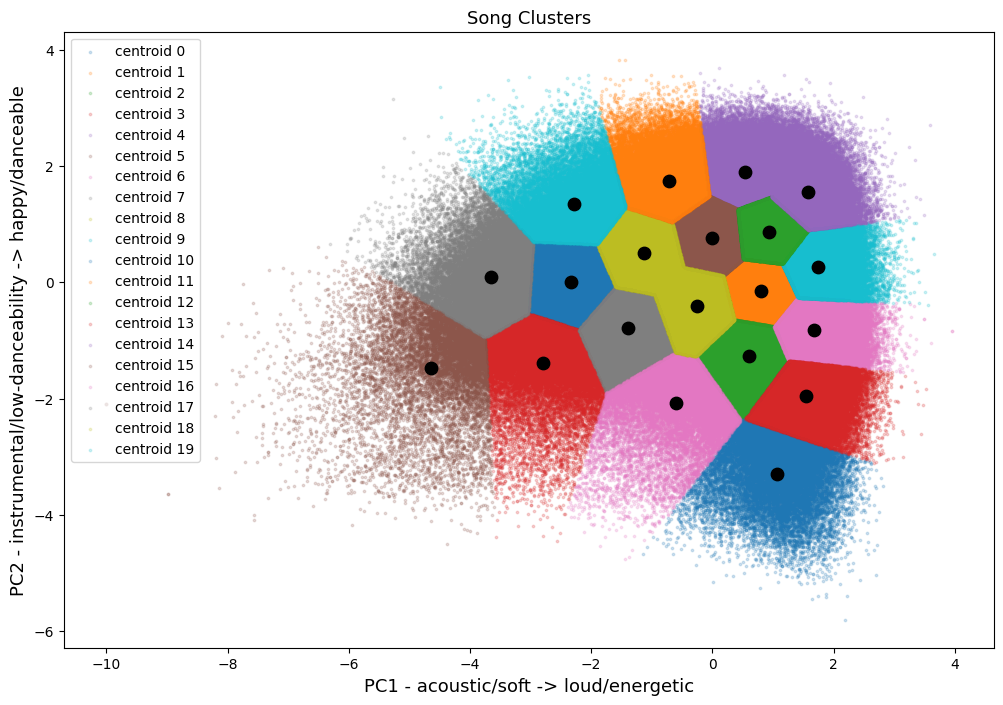

In [23]:
## My source for using pca to visualize the kmeans clusters found from "https://www.askpython.com/python/examples/plot-k-means-clusters-python"
## PCA to reduce the dimensionality and reduced repetitive features weights


pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

## Used to read the weights of each features after printing graph, found on "https://stackoverflow.com/questions/47370795/pca-on-sklearn-how-to-interpret-pca-components"
pca_weights = pd.DataFrame(pca.components_, columns=features)

## Kmeans to create 20 clusters as found by WCSS
kmeans = KMeans(n_clusters=20, random_state=42)
songs["cluster"] = kmeans.fit_predict(pca_features)

## Get the labels for clusters chosen to be used to color coat the graph and for for loop length
labels = songs["cluster"].values
u_labels = np.unique(labels)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(12, 8))
for i in u_labels:
    plt.scatter(pca_features[labels == i, 0], pca_features[labels == i, 1], label = "centroid "+ str(i), s=3, alpha=0.2)

plt.scatter(centroids[:, 0], centroids[:, 1], s=80, color='k')
plt.xlabel('PC1 - acoustic/soft -> loud/energetic', fontsize=13)
plt.ylabel('PC2 - instrumental/low-danceability -> happy/danceable', fontsize=13)
plt.title('Song Clusters', fontsize=13)
plt.legend(fontsize=10)
plt.show()

### Looking at the graph we can see that PCA allows me to represent the data in a 2D space showing distinct areas that genres of music fall into. Next I am going to pick a small playlist of 5 songs within the same genre to see if this relationship coorelates to the graph

In [15]:
## This shows how the two principal components sort the songs based on effectivesness
print(pca_weights.round(3))

   danceability  energy    key  loudness   mode  speechiness  acousticness  \
0         0.055   0.583  0.036     0.532 -0.092        0.148        -0.513   
1         0.655  -0.094  0.039    -0.004 -0.038        0.129         0.114   

   instrumentalness  liveness  valence  tempo  
0            -0.008     0.110    0.182  0.187  
1            -0.385    -0.185    0.566 -0.163  


#### Observing the outputs, we find that PC1 is primarily focused on Energy (.586), Loudness (.535), and Aucousticness (-.514). This explains that PC1 is sorting based on if the song is loud and exciting versus if its softer or calm. In PC2 its primarily focused on the features Dancibility (.655), Instrumentallness (-.389), and valence (.570). This indicates that PC2 is sorting based on happy and danceable tracks (similar to party music) versus instramental or less happy/exciting songs.

## Observing Genres to see if they fit into specific clusters/similar areas of mus

In [41]:
## These first three were test playlists I created myself to check if trends showed up
country_playlist = {
    ("When it rains it pours", "Luke Combs"),
    ("She Got the best of me", "Luke Combs"),
    ("Play it again", "Luke Bryan"),
    ("make me wanna", "Thomas Rhett"),
    ("honey bee", "Blake Shelton"),
    ("Toes", "Zac Brown Band"),
    ("Good Good", "Florida Georgia Line"),
    ("tennessee whiskey", "Chris Stapleton"),
    ("check yes or no", "george strait"),
    ("the gambler", "kenny rogers"),
    ("whiskey glasses", "morgan wallen"),
    ("cruise", "florida georgia line"),
    ("american kids", "kenny chesney"),
    ("9 to 5", "dolly parton"),
    ("die a happy man", "sam hunt"),
    ("rhinestone cowboy", "glen campbell"),
    ("Two dozen roses", "shenandoah"),
    ("as good as i once was", "toby keith"),
    ("Girl Crush", "little big town"),
    ("strawberry wine", "deana carter"),
    ("somebody like you", "tim mcgraw"),
    ("watching you", "rodney atkins"),
    ("just to see you smile", "tim mcgraw"),
    ("amazed", "lonestar"),
    ("I like it, i love it", "tim mcgraw"),
    ("pickup man", "joe diffie"),
    ("achy breaky heart", "billy ray cyrus"),
    ("the kiss", "faith hill"),
    ("our song", "taylor swift"),
    ("the good stuff", "kenny chesney"),
    ("Peter Pan", "kelsea ballerini"),
    ("act naturally", "buck owens"),
    ("my church", "maren morris"),
    ("don't rock the jukebox", "alan jackson"),
    ("lesson in leavin'", "jo dee messina"),
    ("big city", "merle haggard"),
    ("love, me", "collin raye"),
    ("daddy sang bass", "johnny cash"),
    ("it's just a matter of time", "randy travis"),
    ("teddy bear", "red sovine"),
    ("high cotton", "alabama"),
    ("behind closed doors", "charlie rich"),
    ("black sheep", "John anderson"),
}

rocknroll_playlist = {
    ("highway to hell", "AC/dc"),
    ("Kryptonite", "3 doors down"),
    ("welcome to the jungle", "Guns N' Roses"),
    ("more than a feeling", "boston"),
    ("under the bridge", "red hot chili peppers"),
    ("enter sandman", "metallica"),
    ("carry on wayward son", "kansas"),
    ("tom sawyer", "rush"),
    ("renegade", "styx"),
    ("Crazy train", "ozzyosbourne"),
    ("jessie's girl", "rick springfield"),
    ("my curse", "killswitch engage"),
    ("zombie", "the cranberries"),
    ("we're not gonna take it", "twisted sister"),
    ("once bitten twice shy", "great white"),
    ("barracuda", "heart"),
    ("dream on", "aerosmith"),
    ("heat of the moment", "asia"),
    ("in the end", "linkin park"),
    ("mr. brightside", "the killers"),
    ("purple rain", "prince"),
    ("black hole sun", "soundgarden"),
    ("footloose", "kenny loggins"),
    ("18 and life", "skid row"),
    ("cocaine", "eric clapton"),
    ("billie jean",""),
    ("give a little bit","supertramp"),
    ("roxanne","the police"),
    ("cold as ice","foreigner"),
    ("i want candy","bow wow wow"),
    ("i melt with you","modern english"),
    ("just what i needed","the cars"),
    ("I love rock 'n roll","Joan Jett & The Blackhearts"),
    ("you got it","roy orbison"),
    ("i ran","a flock of seagulls"),
    ("manic monday","the bangles"),
    ("we're not gonna take it","twisted sister"),
    ("good times roll","the cars"),
    ("raise a little hell","trooper"),
    ("you might think","the cars"),
    ("turn up the radio","autograph"),
    ("rich girls","daryl hall & john oates"),
    ("summertime blues","eddie cochran"),
}

rnb_playlist = {
    ("love","keyshia cole"),
    ("no one","alicia keys"),
    ("100","ella mai"),
    ("take a bow","rihanna"),
    ("so sick","ne-yo"),
    ("rehab","rihanna"),
    ("cry me a river","justin timberlake"),
    ("heaven sent","keyshia cole"),
    ("slamorous","studio allstars"),
    ("burn","usher"),
    ("long way 2 go","cassie"),
    ("if i ain't got you","alicia keys"),
    ("try again","aaliyah"),
    ("because of you","ne-yo"),
    ("come with me","mira"),
    ("bleeding love","leona lewis"),
    ("me & u","cassie"),
    ("closer","ne-yo"),
    ("seperated","avant"),
    ("birthday sex","jeremih"),
    ("like a boy","ciara"),
    ("one wish","ray j"),
    ("u got it bad","usher"),
    ("foolish","ashanti"),
    ("must be nice","lyfe jennings"),
    ("if this isn't love","jennifer hudson"),
    ("sexy love","ne-yo"),
    ("rock your body","justin timberlake"),
    ("how do i breathe","mario"),
    ("cater 2 u","destiny's child"),
    ("promise","ciara"),
    ("prove myself","ant utama"),
    ("i should have cheated","keyshia cole"),
    ("promise","jagged edge"),
    ("angels cry","mariah carey"),
    ("happy","ashanti"),
    ("walking away","craig david"),
    ("contaigous","the isley brothers"),
    ("makin' good love","avant"),
    ("so gone","monica"),
    ("walked outta heaven","jagged edge"),
    ("love","musiq soulchild"),
    ("never never land","lyfe jennings"),
    ("if i  didn't know better","luther vandross")
}

jb_playlist = {
    ("baby", "justin Bieber"),
    ("U smile", "justin Bieber"),
    ("somebody to love", "justin bieber"),
    ("boyfriend", "justin bieber"),
    ("Die in your arms", "justin bieber"),
    ("one love", "justin bieber"),
    ("be alright", "justin bieber"),
    ("believe", "justin bieber"),
}

similar_playlist = {
    ("supersonic", "J.J. frad"),
    ("ice ice baby", "Vanilla Ice"),
    ("you give love a bad name", "bon jovi"),
    ("pur some sugar on me", "def leppard"),
    ("misery business", "paramore"),
    ("wonderwall", "oasis"),
    ("super freak", "rick james"),
    ("U Can't Touch This", "MC hammer"),
}

## These are friends playlist to see if there are correlations in music based on their preferences
max_playlist = {
    ("way back", "Travis Scott"),
    ("Alright", "Kendrick Lamar"),
    ("hold my liquor", "kanye west"),
    ("starboy", "The Weeknd;Daft Punk"),
    ("Gatti", "JACKBOYS"),
    ("Myron", "Eternal Atake (Deluxe) - LUV vs. The World 2"),
    ("OUTERSPACE (feat. Baby Keem)", "Don Toliver"),
    ("headlines", "drake"),
    ("dreams and nightmares", "meek mill"),
    ("Black Skinhead", "Kanye West"),
    ("stronger", "kanye west"),
    ("power", "kanye west"),
    ("Freeee (Ghost Town Pt. 2)", "KIDS SEE GHOSTS, Ty Dolla $ign"),
}

casey_playlist = {
    ("impossible", "travis scott"),
    ("Don't Lose Me", "Offset"),
    ("Honest", "Baby Keem"),
    ("Scared Of Love", "Juice WRLD"),
    ("Without You", "The Kid LAROI"),
    ("SELFISH", "The Kid LAROI"),
    ("Sept. 16", "Kid Cudi"),
    ("Reminds Me Of You", "Juice WRLD, The Kid LAROI"),
    ("Good Days", "SZA"),
    ("Scared Of Love", "Juice WRLD"),
    ("NI BIEN NI MAL", "Bad Bunny"),
}

cap_playlist = {
    ("Backseat Serenade", "All Time Low"),
    ("Miserable At Best", "Mayday Parade"),
    ("Kids In Love", "Red Car Wire"),
    ("Lullabies", "All Time Low"),
    ("Weightless", "All Time Low"),
    ("The Only Reason", "5 Seconds of Summer"),
    ("Disconnected", "Cowboy Mouth"),
    ("Stay", "Mayday Parade"),
    ("505", "Arctic Monkeys"),
    ("18", "Anarbor"),
    ("MORBID MIND", "Jack Kays"),
    ("18", "5 Seconds of Summer"),
    ("i swear this time i mean it", "Mayday Parade"),
    ("If these sheets were states", "all time low"),
    ("therapy", "all time low"),
    ("Remembering sunday", "all time low"),
    ("English love affair", "5 seconds of summer"),
    ("body bag (feat. yungblud & bert mccracken of the used)", "Machine Gun Kelly"),
}

cody_playlist = {
    ("Good Vibes", "Chris Janson"),
    ("Blue Ain't Your Color", "Keith Urban"),
    ("Small Town Boy", "Dustin Lynch"),
    ("How country feels", "randy houser"),
    ("write this down", "george strait"), 
    ("cold as you", "luke combs"),
    ("sweet home alabama", "lynyrd skynyrd"),
    ("My kinda party", "jason aldean"),
    ("redneck yacht club", "craig morgan"),
    ("night train", "jason aldean"), 
    ("i go back", "kenny chesney"),
    ("american kids", "kenny chesney"),
    ("heartache on the dance floor", "jon pardi"),
    ("better together", "luke combs"),
    ("wasted on you", "morgan wallen"), 
    ("done", "chris janson"),
    ("dirt road anthem", "jason aldean"),
    ("six feet apart", "luke combs"),
    ("one margarita", "luke bryan"),
    ("would you go with me", "josh turner"), 
}

sad_playlist = {
    ("if you want love", "nf"),
    ("jealous", "labrinth"),
    ("jocelyn flores", "xxxtentacion"),
    ("changes", "xxxtentacion"),
    ("lost boy", "ruth b."),
    ("selfish", "pnb rock"),
    ("bruises", "lewis capaldi"),
    ("how to save a life", "the fray"),
    ("a drop in the ocean", "ron pope"),
    ("happier", "ed sheeran"),
    ("lie", "nf"),
    ("unsteady", "x ambassadors"),
    ("not about angels", "birdy"),
    ("losin control", "russ"),
    ("idfc", "blackbear"),
    ("i'm sorry", "joyner lucas"),
    ("be alright", "dean lewis"),
    ("you are the reason", "calum scott"),
    ("little do you know", "alex & sierra"),
    ("it's you", "ali gatie"),
    ("skinny love", "birdy"),
    ("one day", "tate mcrae"),
    ("can i be him", "james arthur"),
    ("already gone", "sleeping at last"),
    ("sorry", "halsey"),
}

low_energy = {
    ("come back to earth", "mac miller"),
    ("never came back", "the kid laroi"),
    ("heartbreak anniversary", "giveon"),
    ("save my soul", "noah rinker"),
    ("SLOW DANCING IN THE DARK", "Joji"),
    ("superpowers", "daniel caesar"),
    ("off my face", "justin bieber"),
    ("skin", "hans williams"),
    ("woods", "mac miller"),
    ("you were good to me", "jeremy zucker"),
    ("willows", "hans williams"),
    ("slow dancing in a burning room", "john mayor"),
    ("loose", "daniel caesar"),
    ("something in the orange", "zach bryan"),
    ("marvins room", "drake"),
    ("home", "nf"),
    ("traitor", "olivia rodrigo"),
    ("mistake", "nf"),
    ("miserable man", "david kushner"),
}




In [35]:
songs[songs["name"].str.lower() == "I love rock 'n roll".lower()]

# songs[(songs["name"].str.lower() == "stay".lower()) & (songs["artists"].str.lower() == "mayday parade".lower())]

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,signature,cluster
319513,2Cdvbe2G4hZsnhNMKyGrie,I Love Rock 'N Roll,I Love Rock 'N' Roll (Expanded Edition),Joan Jett & The Blackhearts,0.535,0.716,4,-5.025,1,0.0431,0.326,0.0,0.659,0.901,94.379,175173.0,i saw him dancin there by the record machine i...,"[5460278, 1296532, 3525771, 4315474, 243683, 1...",12


### Functions for checking similarity based on either a playlist, or an artist

In [19]:
## This function requires a playlist
def check_playlist_clusters(playlist):
    playlist_songs = []

    for name, artist in playlist:
    
        song = songs[(songs["name"].str.lower() == name.lower()) & (songs["artists"].str.lower() == artist.lower())]
        if song.empty:
            continue
        
        playlist_songs.append(song.iloc[0])

    playlist_df = pd.DataFrame(playlist_songs)
    
    print(f"\nThis playlist has {len(playlist_df)} songs in dataset")
    print("Total unique clusters: ", playlist_df["cluster"].nunique())
    print("\nCluster Distribution: ", playlist_df["cluster"].value_counts())

## This function will scan every song the artist explicitly sings
def check_artist_clusters(artist_name):

    artist_songs = songs[songs["artists"].str.lower() == artist_name.lower()]
    print(f"\n{artist_name} has {len(artist_songs)} songs in dataset")
    print("Total unique clusters: ", artist_songs["cluster"].nunique())
    print("\nCluster Distribution: ", artist_songs["cluster"].value_counts())
    


### Testing Methods with artists and playlists

In [20]:
## Test artist

# check_artist_clusters("Katy Perry")
# check_artist_clusters("Justin Bieber")
check_artist_clusters("lil baby")



lil baby has 110 songs in dataset
Total unique clusters:  9

Cluster Distribution:  cluster
5     31
12    27
4     18
1     17
18     7
14     6
11     2
0      1
8      1
Name: count, dtype: int64


## These methods allow me to overlap the artists songs or created playlists overtop the PCA graph to see if there are trends 

In [27]:

def view_artist_overlay(artist_name):

    artist_songs = songs[songs["artists"].str.lower() == artist_name.lower()]
    if artist_songs.empty:
        print("This artist wasn't found")
        return

    song_indexes = artist_songs.index

    plt.figure(figsize=(12, 8))

    #sample
    for i in u_labels:
        plt.scatter(pca_features[labels == i, 0], pca_features[labels == i, 1], s=3, alpha=0.2)

    #artists songs
    plt.scatter(
        pca_features[song_indexes, 0], pca_features[song_indexes, 1], color="Black", s=70, label= artist_name+" songs"
    )

    plt.scatter(pca_features[song_indexes, 0], pca_features[song_indexes, 1], s=80, color='k')
    plt.xlabel('PC1 - quiet/acoustic -> loud/energetic', fontsize=13)
    plt.ylabel('PC2 - instrumental -> danceable', fontsize=13)
    plt.title(f"Plotting the artist: {artist_name} on previously found PCA graph")
    plt.legend(fontsize=10)
    plt.show()



    

def view_playlist_overlay(playlist):

    playlist_songs = []

    for name, artist in playlist:
    
        song = songs[(songs["name"].str.lower() == name.lower()) & (songs["artists"].str.lower() == artist.lower())]
        if song.empty:
            print(f"{name} not found")
            continue
        
        playlist_songs.append(song.index[0])

    song_indexes = playlist_songs


    plt.figure(figsize=(12, 8))

    #sample
    for i in u_labels:
        plt.scatter(pca_features[labels == i, 0], pca_features[labels == i, 1], s=3, alpha=0.2)

    #artists songs
    plt.scatter(
        pca_features[song_indexes, 0], pca_features[song_indexes, 1], color="Black", s=70, label= "Songs"
    )

    plt.scatter(pca_features[song_indexes, 0], pca_features[song_indexes, 1], s=80, color='k')
    plt.xlabel('PC1 - quiet/acoustic -> loud/energetic', fontsize=13)
    plt.ylabel('PC2 - instrumental -> danceable', fontsize=13)
    plt.title(f"Plotting the playlist on previously found PCA graph")
    plt.legend(fontsize=10)
    plt.show()



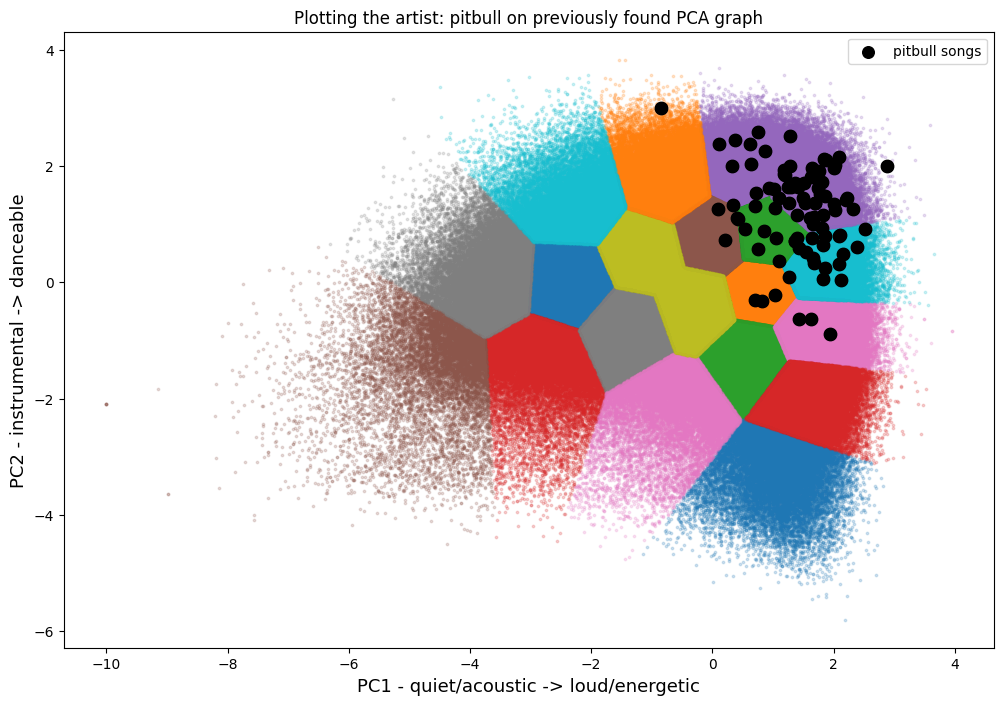

In [52]:
view_artist_overlay("pitbull")
# view_playlist_overlay(rnb_playlist)

In [64]:
## Helped with how to find nearest neighbors using pca/kmeans output here "https://stackoverflow.com/questions/12369484/searching-for-k-nearest-points"
knn = NearestNeighbors(n_neighbors=10)
knn.fit(pca_features)

def PCA_nearest_neighbor(song_name, artist_name):
    print(f"{song_name} By: {artist_name}\n")
    song_index = find_song_index(song_name, artist_name)

    ## nearestNeighbors expects a table of entries, was a single entry previously
    song = pca_features[song_index].reshape(1, 2)
    n_neighbors = knn.kneighbors(song)
    # print(n_neighbors)
    ## n_neighbors return (([[..., ...]]), ([[..., ...]]))
    n_indexes = n_neighbors[1][0]
    
    count = 1
    ## Loops to get the name and artist from songs dataframe using the index from the nearest neighbor output form nearest neighbors
    for i in range(len(n_indexes)):
        #N-indexes at location i represents the neighbors index in the songs datafram
        nn_name = songs["name"].iloc[n_indexes[i]]
        nn_artist = songs["artists"].iloc[n_indexes[i]]

        print(f"{count}. {nn_name} by: {nn_artist}")
        count += 1

    return

print(PCA_nearest_neighbor("stuck on you", "giveon"))

stuck on you By: giveon

1. Stuck On You by: Giveon
2. Within A Room Somewhere (Demo) by: Sixpence None The Richer
3. Octavo Día by: Shakira
4. Ten New Lives by: Molly Nilsson
5. Hello, Dolly! (from Hello, Dolly!) by: Frank Sinatra, Count Basie
6. Suela de alpargata by: Barricada
7. Dear John by: Taylor Swift
8. Developing Active People by: Via Audio
9. Closed Mouths by: Trey Songz
10. Streets by: Vybz Kartel
None


---- Here are Marvins Room by Drake's most similar songs ----
1. Not Going Back | Similarity Score = 0.22
2. Overtime | Similarity Score = 0.22
3. Stronger Than I Was | Similarity Score = 0.22
4. W.I.P. Megamix | Similarity Score = 0.22
5. deserveumore | Similarity Score = 0.22
6. Betrayal | Similarity Score = 0.21
7. Drifting | Similarity Score = 0.21
8. Holding On | Similarity Score = 0.21
9. Kiss Land | Similarity Score = 0.21
10. Still the Same | Similarity Score = 0.21
[(493871, 0.22), (520842, 0.22), (652512, 0.22), (761189, 0.22), (817194, 0.22), (75236, 0.21), (188689, 0.21), (298982, 0.21), (375678, 0.21), (648567, 0.21)]